# Self-Supervised pre-training (SimCLR) на своих изображениях с LightlySSL

1. Берем **изображения без разметки** (папка с `.jpg/.png/...`).
2. Делаем **self-supervised предобучение** методом **SimCLR** (contrastive learning) с помощью **LightlySSL**.
3. Применяем предобученный backbone к **downstream задаче**: **поиск похожих изображений (image retrieval)**.

Почему так:
- SimCLR учит сеть выделять устойчивые визуальные признаки без меток (две аугментации одного изображения должны иметь близкие представления).
- Retrieval — очень практичная задача CV и не требует разметки, при этом хорошо демонстрирует пользу предобученных эмбеддингов.

## Что нужно от окружения
- `torch`, `torchvision`
- `lightly`
- `PIL`, `tqdm`, `matplotlib`




In [7]:
import importlib
import sys
from pathlib import Path

def find_existing_file(candidate_paths: list[Path]) -> Path:
    for p in candidate_paths:
        if p.exists():
            return p
    raise FileNotFoundError("Could not find requirements.txt. Tried: " + ", ".join(map(str, candidate_paths)))

cwd = Path.cwd().resolve()
candidate_rel = [
    Path("requirements.txt"),
    Path("ssl_lightly/requirements.txt"),
    Path("ImageProcessingAndRecognition/ssl_lightly/requirements.txt"),
]
candidates = []
for base in [cwd, *cwd.parents]:
    candidates.extend([base / rel for rel in candidate_rel])

req_path = find_existing_file(candidates)
BASE_DIR = req_path.parent
try:
    importlib.import_module("lightly")
except ModuleNotFoundError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_path)])


In [8]:
import os
import random
import time
from dataclasses import dataclass
from typing import Iterable

import matplotlib.pyplot as plt
import torch
import torchvision
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from lightly.loss import NTXentLoss
from lightly.models.modules import SimCLRProjectionHead
from lightly.transforms.simclr_transform import SimCLRTransform

print("python:", sys.version.split()[0])
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
import lightly
print("lightly:", lightly.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


python: 3.13.7
torch: 2.9.1
torchvision: 0.24.1
lightly: 1.5.22
device: cpu


## 1) Данные

Берем изображения из уже имеющегося датасета в репозитории:

- train: `Dataset/images/train`
- val: `Dataset/images/val`

Важно: для self-supervised **разметка не нужна**, достаточно только изображений.

Чтобы тетрадка выполнялась быстро, далее мы **берем небольшой поднабор** (например, 128–256 изображений) и учим 1–2 эпохи.
Для “настоящего” обучения увеличьте `PRETRAIN_EPOCHS`, `PRETRAIN_NUM_IMAGES`, `BATCH_SIZE`.


In [9]:
PROJECT_ROOT = BASE_DIR.parent
TRAIN_DIR = BASE_DIR / "dataset/images/train"
VAL_DIR = BASE_DIR / "dataset/images/val"

# fallback на исходный датасет из проекта (если кто-то удалил dataset из ssl_lightly)
if not TRAIN_DIR.exists() or not VAL_DIR.exists():
    TRAIN_DIR = PROJECT_ROOT / "ImageProcessingAndRecognition/Dataset/images/train"
    VAL_DIR = PROJECT_ROOT / "ImageProcessingAndRecognition/Dataset/images/val"

assert TRAIN_DIR.exists(), f"Not found: {TRAIN_DIR}"
assert VAL_DIR.exists(), f"Not found: {VAL_DIR}"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def iter_image_paths(root: Path) -> Iterable[Path]:
    for dirpath, _, filenames in os.walk(root):
        for filename in filenames:
            path = Path(dirpath) / filename
            if path.suffix.lower() in IMG_EXTS:
                yield path

train_paths_all = sorted(iter_image_paths(TRAIN_DIR))
val_paths_all = sorted(iter_image_paths(VAL_DIR))
print("train images:", len(train_paths_all))
print("val images:", len(val_paths_all))


train images: 200
val images: 100


In [10]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# Попросили “обучить побольше эпох”.
# Эти параметры можно уменьшить, если нужно просто быстро проверить пайплайн.
PRETRAIN_NUM_IMAGES = len(train_paths_all)  # используем все train-изображения из dataset/

# По просьбе преподавателя: учим заметно больше эпох.
# Если нужно просто быстро проверить пайплайн, поставьте FAST_DEMO=True.
FAST_DEMO = False
PRETRAIN_EPOCHS = 10 if FAST_DEMO else (200 if device.type == "cuda" else 150)
IMG_SIZE = 96
BATCH_SIZE = 32
LR = 0.2 if device.type == "cuda" else 0.15
TEMPERATURE = 0.5
NUM_WORKERS = 0
USE_AMP = (device.type == "cuda")

train_paths = train_paths_all[: min(PRETRAIN_NUM_IMAGES, len(train_paths_all))]
val_paths = val_paths_all[: min(200, len(val_paths_all))]

print("subset train:", len(train_paths))
print("subset val:", len(val_paths))


subset train: 200
subset val: 100


## 2) Self-Supervised pre-training: SimCLR

### Что происходит в SimCLR

Для каждого изображения делаем **две сильные аугментации** (два “view”):

- случайный crop/resize,
- color jitter,
- blur и т.п.

Сеть должна:
- сделать представления двух view **похожими** (positive pair),
- а представления разных изображений в батче — **непохожими**.

В LightlySSL это уже реализовано:
- `SimCLRTransform` — генерирует (x0, x1)
- `SimCLRProjectionHead` — MLP “голова”
- `NTXentLoss` — contrastive loss


In [11]:
class ImagePathDataset(Dataset):
    def __init__(self, paths: list[Path], transform):
        self.paths = list(paths)
        self.transform = transform
        if not self.paths:
            raise ValueError("Empty image list")

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        path = self.paths[idx]
        with Image.open(path) as img:
            img = img.convert("RGB")
        x = self.transform(img)
        return x, 0


@dataclass(frozen=True)
class BackboneSpec:
    name: str
    out_dim: int


BACKBONES = {
    "resnet18": BackboneSpec("resnet18", 512),
    "resnet34": BackboneSpec("resnet34", 512),
    "resnet50": BackboneSpec("resnet50", 2048),
}


class SimCLR(nn.Module):
    def __init__(self, backbone: nn.Module, backbone_out_dim: int):
        super().__init__()
        self.backbone = backbone
        self.projection_head = SimCLRProjectionHead(backbone_out_dim, 2048, 2048)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x).flatten(start_dim=1)
        return self.projection_head(x)


BACKBONE_NAME = "resnet18"
spec = BACKBONES[BACKBONE_NAME]
resnet = getattr(torchvision.models, spec.name)(weights=None)
backbone = nn.Sequential(*list(resnet.children())[:-1])

model = SimCLR(backbone, spec.out_dim).to(device)
criterion = NTXentLoss(temperature=TEMPERATURE)
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

transform = SimCLRTransform(input_size=IMG_SIZE)
train_ds = ImagePathDataset(train_paths, transform=transform)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

print("train batches:", len(train_loader))


train batches: 6


/var/folders/gc/dllt6wnd1bbch058cf7hyl9m0000gn/T/ipykernel_43408/1625247744.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


pretrain epoch 1/150: 100%|██████████| 6/6 [00:05<00:00,  1.16it/s, loss=4.13]


epoch 1: loss=4.0581 lr=0.14998


pretrain epoch 2/150: 100%|██████████| 6/6 [00:04<00:00,  1.28it/s, loss=4.13]


epoch 2: loss=4.0712 lr=0.14993


pretrain epoch 3/150: 100%|██████████| 6/6 [00:04<00:00,  1.28it/s, loss=3.79]


...

epoch 148: loss=3.5543 lr=0.00007


pretrain epoch 149/150: 100%|██████████| 6/6 [00:05<00:00,  1.20it/s, loss=3.73]


epoch 149: loss=3.5677 lr=0.00002


pretrain epoch 150/150: 100%|██████████| 6/6 [00:04<00:00,  1.22it/s, loss=3.46]

epoch 150: loss=3.5542 lr=0.00000
pretrain done in 740.6s


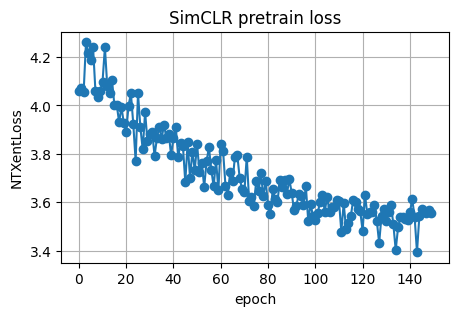

In [12]:
model.train()
loss_history = []
t0 = time.time()

# Baseline для сравнения: эмбеддинги до SSL-обучения (случайная инициализация backbone).
import copy
baseline_backbone_state = copy.deepcopy(model.backbone.state_dict())
baseline_model_state = copy.deepcopy(model.state_dict())

# Небольшое улучшение стабильности: cosine LR schedule по эпохам.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PRETRAIN_EPOCHS)

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    running = 0.0
    pbar = tqdm(train_loader, desc=f"pretrain epoch {epoch}/{PRETRAIN_EPOCHS}")
    for (x0, x1), _ in pbar:
        x0 = x0.to(device, non_blocking=True)
        x1 = x1.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=USE_AMP):
            z0 = model(x0)
            z1 = model(x1)
            loss = criterion(z0, z1)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += float(loss.detach().cpu())
        pbar.set_postfix(loss=float(loss.detach().cpu()))

    avg_loss = running / max(1, len(train_loader))
    loss_history.append(avg_loss)
    scheduler.step()
    lr_now = scheduler.get_last_lr()[0]
    print(f"epoch {epoch}: loss={avg_loss:.4f} lr={lr_now:.5f}")

print(f"pretrain done in {(time.time() - t0):.1f}s")
plt.figure(figsize=(5, 3))
plt.plot(loss_history, marker="o")
plt.title("SimCLR pretrain loss")
plt.xlabel("epoch")
plt.ylabel("NTXentLoss")
plt.grid(True)
plt.show()


In [13]:
OUT_DIR = BASE_DIR / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("output dir:", OUT_DIR)

# Быстрая проверка "стало лучше":
# Смотрим, насколько модель научилась делать два view одного и того же изображения похожими
# и насколько она отличает view разных изображений.
def pos_neg_stats(simclr_model: nn.Module, loader, num_batches: int = 2):
    simclr_model.eval()
    pos_means = []
    neg_means = []
    with torch.inference_mode():
        for i, batch in enumerate(loader):
            if i >= num_batches:
                break
            (x0, x1), _ = batch
            x0 = x0.to(device, non_blocking=True)
            x1 = x1.to(device, non_blocking=True)
            z0 = torch.nn.functional.normalize(simclr_model(x0), dim=1)
            z1 = torch.nn.functional.normalize(simclr_model(x1), dim=1)
            sim = z0 @ z1.T
            eye = torch.eye(sim.shape[0], dtype=torch.bool, device=sim.device)
            pos_means.append(sim[eye].mean().item())
            neg_means.append(sim[~eye].mean().item())
    pos = sum(pos_means) / max(1, len(pos_means))
    neg = sum(neg_means) / max(1, len(neg_means))
    return pos, neg

baseline_model = copy.deepcopy(model).to(device)
baseline_model.load_state_dict(baseline_model_state)

pos_r, neg_r = pos_neg_stats(baseline_model, train_loader)
pos_s, neg_s = pos_neg_stats(model, train_loader)

print(f"pos/neg cosine (random): pos={pos_r:.4f} neg={neg_r:.4f} margin={pos_r - neg_r:.4f}")
print(f"pos/neg cosine (ssl):    pos={pos_s:.4f} neg={neg_s:.4f} margin={pos_s - neg_s:.4f}")


output dir: /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/output
pos/neg cosine (random): pos=0.9787 neg=0.9758 margin=0.0029
pos/neg cosine (ssl):    pos=0.4800 neg=0.0147 margin=0.4653


## 3) Downstream: поиск похожих изображений (retrieval)

Теперь используем только **backbone** (без projection head), получаем эмбеддинги изображений и находим nearest neighbors по cosine similarity.

Почему это downstream задача:
- мы **не оптимизируем** сеть под retrieval-лосс (в этой тетрадке),
- мы просто применяем предобученные признаки к прикладной задаче.


In [14]:
# Для retrieval используем обычный детерминированный preprocessing
val_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize((IMG_SIZE, IMG_SIZE)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]
)

class SingleViewDataset(Dataset):
    def __init__(self, paths: list[Path], transform):
        self.paths = list(paths)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        path = self.paths[idx]
        with Image.open(path) as img:
            img = img.convert("RGB")
        return self.transform(img), str(path)


def compute_embeddings(embedder: nn.Module, paths_list: list[Path], desc: str, batch_size: int = 64):
    ds = SingleViewDataset(paths_list, transform=val_transform)
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )

    embedder.eval()
    embs = []
    out_paths = []
    with torch.inference_mode():
        for x, p in tqdm(loader, desc=desc):
            x = x.to(device, non_blocking=True)
            e = embedder(x)
            e = torch.nn.functional.normalize(e, dim=1)
            embs.append(e.cpu())
            out_paths.extend(list(p))
    return torch.cat(embs, dim=0), out_paths

# Делаем retrieval по базе из train+val (так больше шансов найти реально похожие примеры)
db_paths = train_paths + val_paths
query_paths = val_paths  # запросы берем из val

# Эмбеддинги после SSL (обученный backbone)
embedder_ssl = nn.Sequential(model.backbone, nn.Flatten(start_dim=1)).to(device)
embs_db_ssl, db_paths_str = compute_embeddings(embedder_ssl, db_paths, desc="embed db (ssl)")
embs_q_ssl, q_paths_str = compute_embeddings(embedder_ssl, query_paths, desc="embed queries (ssl)")

# Baseline: эмбеддинги на backbone ДО обучения (случайная инициализация)
import copy
baseline_backbone = copy.deepcopy(model.backbone).to(device)
baseline_backbone.load_state_dict(baseline_backbone_state)
embedder_random = nn.Sequential(baseline_backbone, nn.Flatten(start_dim=1)).to(device)
embs_db_random, _ = compute_embeddings(embedder_random, db_paths, desc="embed db (random)")
embs_q_random, _ = compute_embeddings(embedder_random, query_paths, desc="embed queries (random)")

print("db size:", len(db_paths_str), "queries:", len(q_paths_str))
print("embeddings db (ssl):", tuple(embs_db_ssl.shape))
print("embeddings db (random):", tuple(embs_db_random.shape))


embed queries (random): 100%|██████████| 2/2 [00:00<00:00,  3.12it/s]

db size: 300 queries: 100
embeddings db (ssl): (300, 512)
embeddings db (random): (300, 512)


In [15]:
TOPK = 6
NUM_QUERIES = 5

# Можно вручную зафиксировать query-картинки (чтобы в отчете всегда был один и тот же удачный пример).
# Пример: MANUAL_QUERY_BASENAMES = ["123.jpg", "tiger.jpg"]
MANUAL_QUERY_BASENAMES: list[str] = []

# Для исключения self-match: сопоставляем путь -> индекс в базе
db_index = {p: i for i, p in enumerate(db_paths_str)}

def topk_and_score(embs_q: torch.Tensor, q_paths: list[str], embs_db: torch.Tensor):
    sims = embs_q @ embs_db.T  # [Q, DB]

    self_idxs = torch.tensor([db_index.get(p, -1) for p in q_paths], dtype=torch.long)
    sims_masked = sims.clone()
    for qi, j in enumerate(self_idxs.tolist()):
        if j >= 0:
            sims_masked[qi, j] = -1e9

    k = min(TOPK, sims.shape[1] - 1) if sims.shape[1] > 1 else 1
    top_vals, top_idxs = torch.topk(sims_masked, k=k, dim=1)

    # mean(all) без self (если self есть в базе)
    gather_idx = self_idxs.clamp_min(0).unsqueeze(1)
    self_sims = sims.gather(1, gather_idx).squeeze(1)
    has_self = (self_idxs >= 0).float()
    denom = sims.shape[1] - has_self
    mean_all = (sims.sum(dim=1) - self_sims * has_self) / denom

    mean_topk = top_vals.mean(dim=1)
    score = mean_topk - mean_all
    return top_vals, top_idxs, score

# SSL: top-k + score
top_vals_ssl, top_idxs_ssl, score_ssl = topk_and_score(embs_q_ssl, q_paths_str, embs_db_ssl)

# Cohesion: насколько соседи похожи друг на друга (помогает выбрать более "логичные" примеры)
# neighbor_embs: [Q, K, D]
neighbor_embs = embs_db_ssl[top_idxs_ssl]
neighbor_sims = torch.einsum('qkd,qld->qkl', neighbor_embs, neighbor_embs)
k = neighbor_sims.shape[1]
eye = torch.eye(k, dtype=torch.bool).unsqueeze(0)
cohesion = (neighbor_sims.masked_fill(eye, 0.0).sum(dim=(1, 2)) / (k * (k - 1)))

# Итоговый скоринг для выбора query
final_score = score_ssl + 0.25 * cohesion

# Выбираем query
if MANUAL_QUERY_BASENAMES:
    selected = []
    for base in MANUAL_QUERY_BASENAMES:
        # ищем в query_paths по basename
        matches = [i for i, p in enumerate(q_paths_str) if Path(p).name == base]
        if matches:
            selected.append(matches[0])
    selected = selected[:NUM_QUERIES]
else:
    order = torch.argsort(final_score, descending=True).tolist()
    selected = []
    SIM_DUP_THR = 0.97
    for qi in order:
        if len(selected) >= NUM_QUERIES:
            break
        if selected:
            sims_q = (embs_q_ssl[qi] @ embs_q_ssl[selected].T).max().item()
            if sims_q > SIM_DUP_THR:
                continue
        selected.append(qi)

print("Selected queries:")
for qi in selected:
    print(
        f"- {q_paths_str[qi]} final={final_score[qi].item():.4f} score={score_ssl[qi].item():.4f} cohesion={cohesion[qi].item():.4f} top1={top_vals_ssl[qi,0].item():.3f}"
    )

def rows_from_topk(selected_qis: list[int], top_idxs: torch.Tensor, top_vals: torch.Tensor):
    rows = []
    for qi in selected_qis:
        rows.append((q_paths_str[qi], top_idxs[qi].tolist(), top_vals[qi].tolist()))
    return rows

rows_ssl = rows_from_topk(selected, top_idxs_ssl, top_vals_ssl)

# Random baseline для тех же query
top_vals_r, top_idxs_r, _ = topk_and_score(embs_q_random, q_paths_str, embs_db_random)
rows_random = rows_from_topk(selected, top_idxs_r, top_vals_r)


Selected queries:
- /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/dataset/images/val/223061.jpg final=0.6678 score=0.4299 cohesion=0.9516 top1=0.987
- /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/dataset/images/val/241004.jpg final=0.6479 score=0.4075 cohesion=0.9616 top1=0.984
- /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/dataset/images/val/106024.jpg final=0.6361 score=0.3975 cohesion=0.9544 top1=0.972
- /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/dataset/images/val/14037.jpg final=0.6278 score=0.3887 cohesion=0.9568 top1=0.968
- /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/dataset/images/val/147091.jpg final=0.6065 score=0.3716 cohesion=0.9396 top1=0.969


saved: /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/output/retrieval_grid_random.png


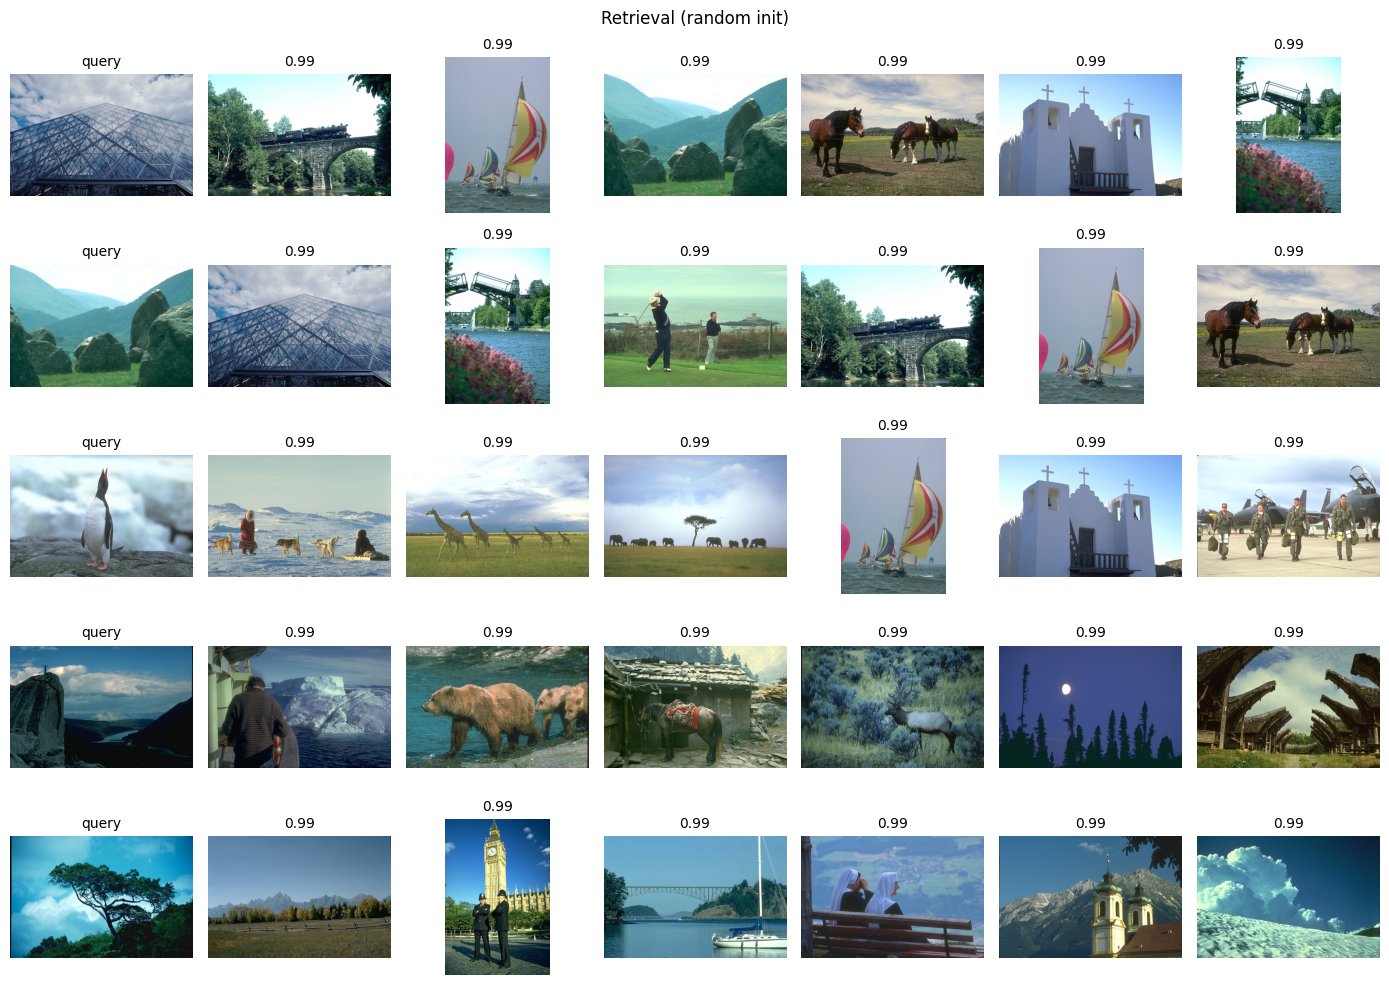

saved: /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/output/retrieval_grid_ssl.png


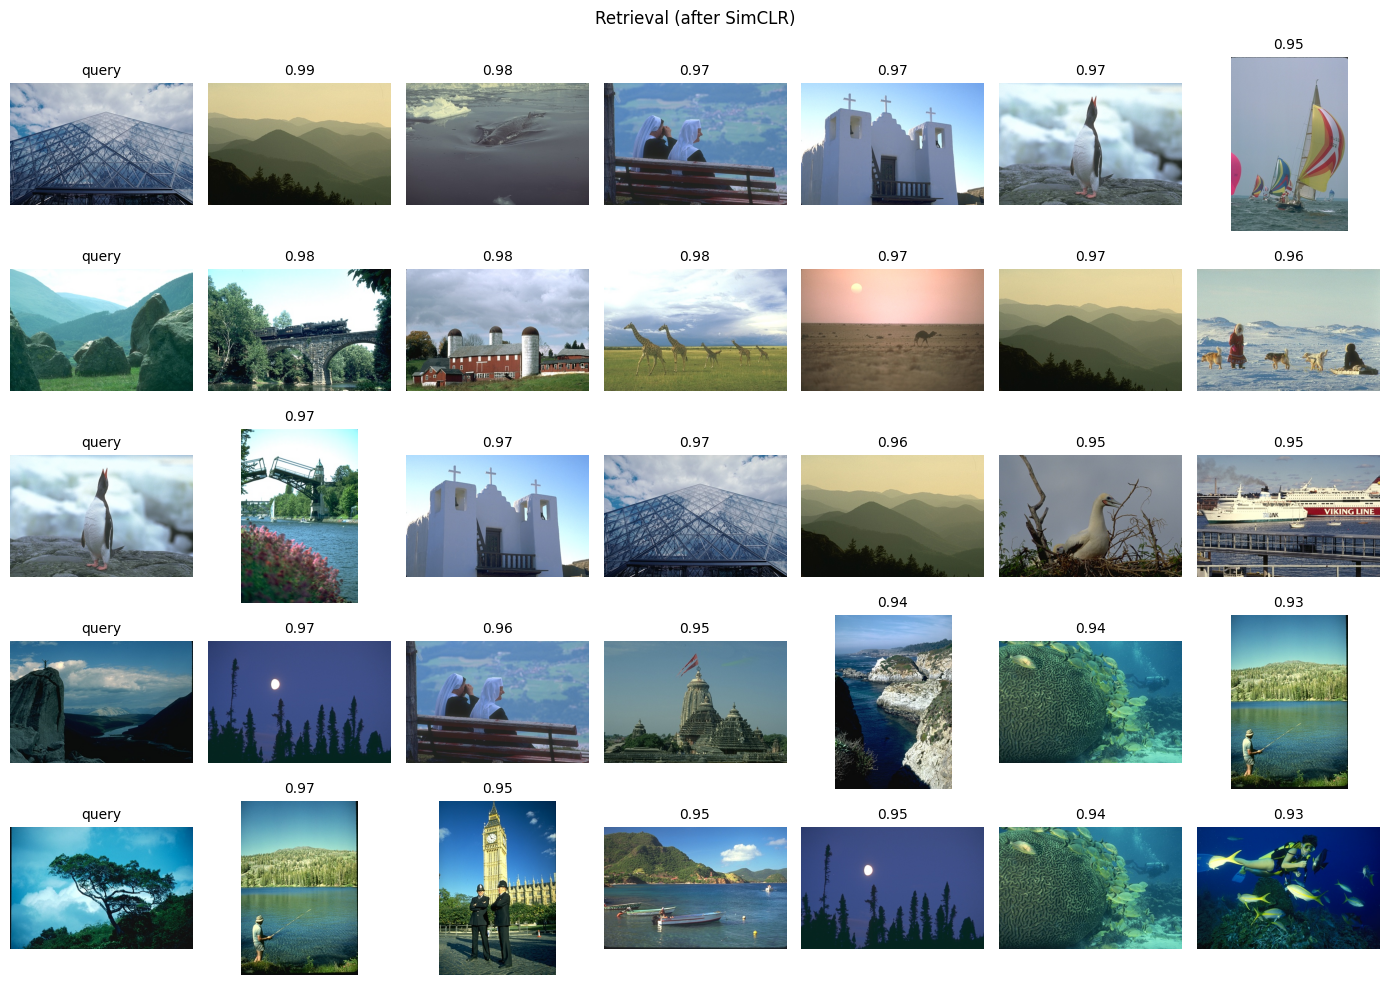

In [16]:
from pathlib import Path

def plot_retrieval(rows, title: str, out_png: Path):
    # rows: (query_path, neighbor_idxs, neighbor_sims)
    n_rows = len(rows)
    n_cols = 1 + TOPK

    fig_w = max(10, 2 * n_cols)
    fig_h = max(2, 2 * n_rows)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
    if n_rows == 1:
        axes = [axes]

    for r, (q_path, idxs, sims) in enumerate(rows):
        # query
        ax0 = axes[r][0]
        with Image.open(q_path) as img:
            ax0.imshow(img.convert("RGB"))
        ax0.set_title("query", fontsize=10)
        ax0.axis("off")

        # neighbors
        for c, (idx, sim) in enumerate(zip(idxs, sims), start=1):
            ax = axes[r][c]
            with Image.open(db_paths_str[idx]) as img:
                ax.imshow(img.convert("RGB"))
            ax.set_title(f"{sim:.2f}", fontsize=10)
            ax.axis("off")

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(out_png, dpi=160)
    print("saved:", out_png)
    plt.show()

plot_retrieval(rows_random, "Retrieval (random init)", OUT_DIR / "retrieval_grid_random.png")
plot_retrieval(rows_ssl, "Retrieval (after SimCLR)", OUT_DIR / "retrieval_grid_ssl.png")
